# Results Analysis

Comprehensive analysis of **ResNet18**, **MobileNetV2**, and **AST** experiments for speech classification.  
Data source: `reports/visualizations/results_summary.csv` (generated by `_collect_results.py`).

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white", "font.size": 11})

CSV = Path("visualizations/results_summary.csv")
df = pd.read_csv(CSV)

# Coerce numeric columns
num_cols = [c for c in df.columns if c not in ("Experiment", "Architecture", "Model Name",
            "Seed List", "Device", "Device Name", "Optimizer", "Balancing",
            "SpecAugment", "Freeze Backbone", "Use Pretrained")]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Short label for plots
df["Label"] = (df["Experiment"]
    .str.replace("resnet18_full_", "", regex=False)
    .str.replace("resnet18_", "", regex=False)
    .str.replace("mobilenetv2_full_", "mv2_", regex=False)
    .str.replace("ast_full_", "ast_", regex=False))

print(f"Loaded {len(df)} experiments, {len(df.columns)} columns")
df[["Experiment", "Architecture", "Seeds", "Test Acc Mean", "Test F1 Mean",
    "Train Time Mean (min)", "Inference Latency Mean (ms)"]].sort_values("Test Acc Mean", ascending=False)


Loaded 19 experiments, 58 columns


,Experiment,Architecture,Seeds,Test Acc Mean,Test F1 Mean,Train Time Mean (min),Inference Latency Mean (ms)
8,resnet18_full_specaugment,resnet18,4,97.9078,96.8742,61.1834,1.0349
6,mobilenetv2_full_specaugment,mobilenetv2,4,97.6481,96.3670,109.3695,1.5184
9,resnet18_full_optimizer_sgd,resnet18,4,97.5713,96.2306,75.3528,0.6017
10,resnet18_full_dropout_p05,resnet18,3,97.4494,96.0705,93.7536,1.1408
11,resnet18_full_lr0003,resnet18,4,97.4433,95.9814,61.6158,0.8436
18,resnet18_full_baseline_no_audio_tweaks,resnet18_no_audio_tweaks,4,97.2787,95.8013,47.3179,0.4270
0,ast_full_dropout_p03,AST,4,97.2751,87.8561,339.6535,6.0982
7,mobilenetv2_full_baseline,mobilenetv2,4,97.2641,95.8190,62.9743,1.1088
12,resnet18_full_baseline,resnet18,4,97.2092,95.6768,24.7755,0.4596
1,ast_full_baseline,AST,4,97.1836,87.6794,312.4628,6.0888


## 1. Architecture Comparison — Best per architecture


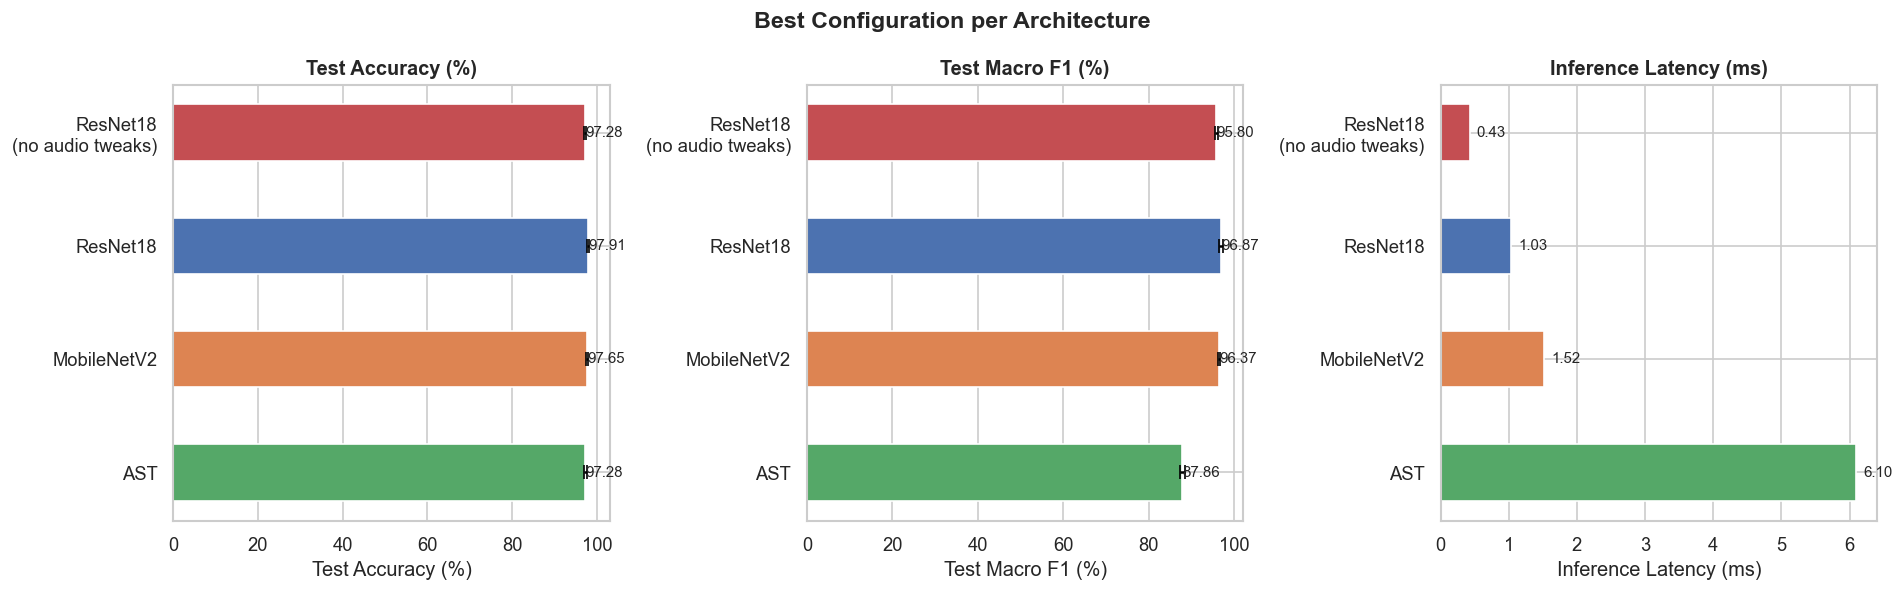

In [2]:
arch_order = ["resnet18", "mobilenetv2", "AST", "resnet18_no_audio_tweaks"]
arch_labels = {"resnet18": "ResNet18", "mobilenetv2": "MobileNetV2",
               "AST": "AST", "resnet18_no_audio_tweaks": "ResNet18\n(no audio tweaks)"}
palette = {"resnet18": "#4C72B0", "mobilenetv2": "#DD8452", "AST": "#55A868",
           "resnet18_no_audio_tweaks": "#C44E52"}

# Best experiment per architecture (highest Test Acc Mean)
best = df.loc[df.groupby("Architecture")["Test Acc Mean"].idxmax()].copy()
best["Arch Label"] = best["Architecture"].map(arch_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [("Test Acc Mean", "Test Acc Std", "Test Accuracy (%)"),
           ("Test F1 Mean",  "Test F1 Std",  "Test Macro F1 (%)"),
           ("Inference Latency Mean (ms)", None, "Inference Latency (ms)")]

for ax, (col, err_col, title) in zip(axes, metrics):
    colors = [palette.get(a, "grey") for a in best["Architecture"]]
    xerr = best[err_col].values if err_col else None
    bars = ax.barh(best["Arch Label"], best[col], xerr=xerr,
                   color=colors, edgecolor="white", height=0.5, capsize=4)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(title)
    for bar, val in zip(bars, best[col]):
        ax.text(bar.get_width() + (0.1 if col == "Inference Latency Mean (ms)" else 0.05),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9)

plt.suptitle("Best Configuration per Architecture", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/arch_comparison_best.png", bbox_inches="tight")
plt.show()


## 2. ResNet18 Ablation Study


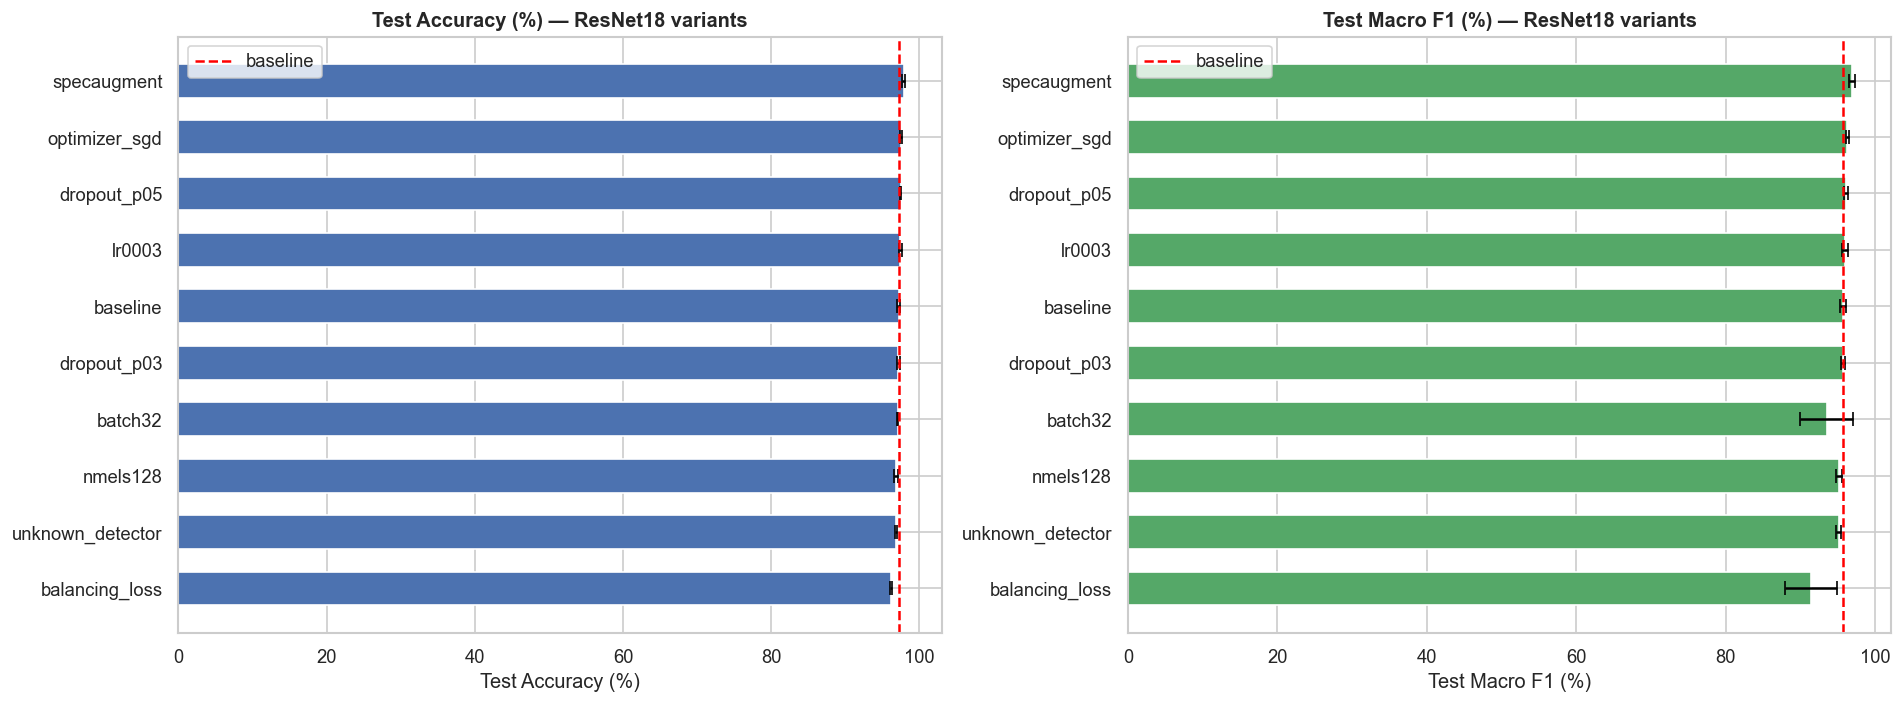

In [3]:
r18 = df[df["Architecture"] == "resnet18"].sort_values("Test Acc Mean", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy with error bars
axes[0].barh(r18["Label"], r18["Test Acc Mean"], xerr=r18["Test Acc Std"],
             color="#4C72B0", edgecolor="white", capsize=4, height=0.6)
axes[0].axvline(r18[r18["Label"] == "baseline"]["Test Acc Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[0].set_title("Test Accuracy (%) — ResNet18 variants", fontweight="bold")
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].legend()

# F1
axes[1].barh(r18["Label"], r18["Test F1 Mean"], xerr=r18["Test F1 Std"],
             color="#55A868", edgecolor="white", capsize=4, height=0.6)
axes[1].axvline(r18[r18["Label"] == "baseline"]["Test F1 Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_title("Test Macro F1 (%) — ResNet18 variants", fontweight="bold")
axes[1].set_xlabel("Test Macro F1 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("visualizations/resnet18_ablation.png", bbox_inches="tight")
plt.show()


## 3. AST Ablation Study


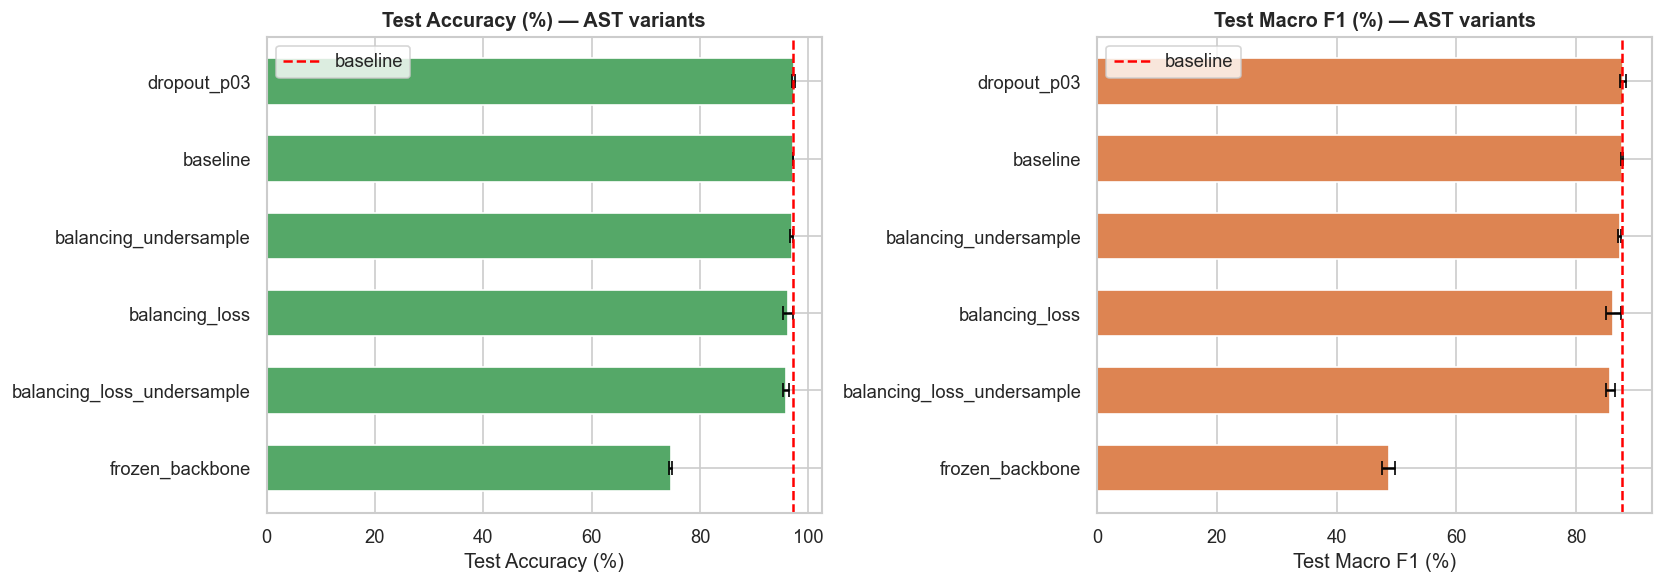

In [4]:
ast = df[df["Architecture"] == "AST"].sort_values("Test Acc Mean", ascending=True).copy()
ast["Label"] = ast["Experiment"].str.replace("ast_full_", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(ast["Label"], ast["Test Acc Mean"], xerr=ast["Test Acc Std"],
             color="#55A868", edgecolor="white", capsize=4, height=0.6)
axes[0].axvline(ast[ast["Label"] == "baseline"]["Test Acc Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[0].set_title("Test Accuracy (%) — AST variants", fontweight="bold")
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].legend()

axes[1].barh(ast["Label"], ast["Test F1 Mean"], xerr=ast["Test F1 Std"],
             color="#DD8452", edgecolor="white", capsize=4, height=0.6)
axes[1].axvline(ast[ast["Label"] == "baseline"]["Test F1 Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_title("Test Macro F1 (%) — AST variants", fontweight="bold")
axes[1].set_xlabel("Test Macro F1 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("visualizations/ast_ablation.png", bbox_inches="tight")
plt.show()


## 4. Efficiency Frontier — Accuracy vs Training Time vs Latency


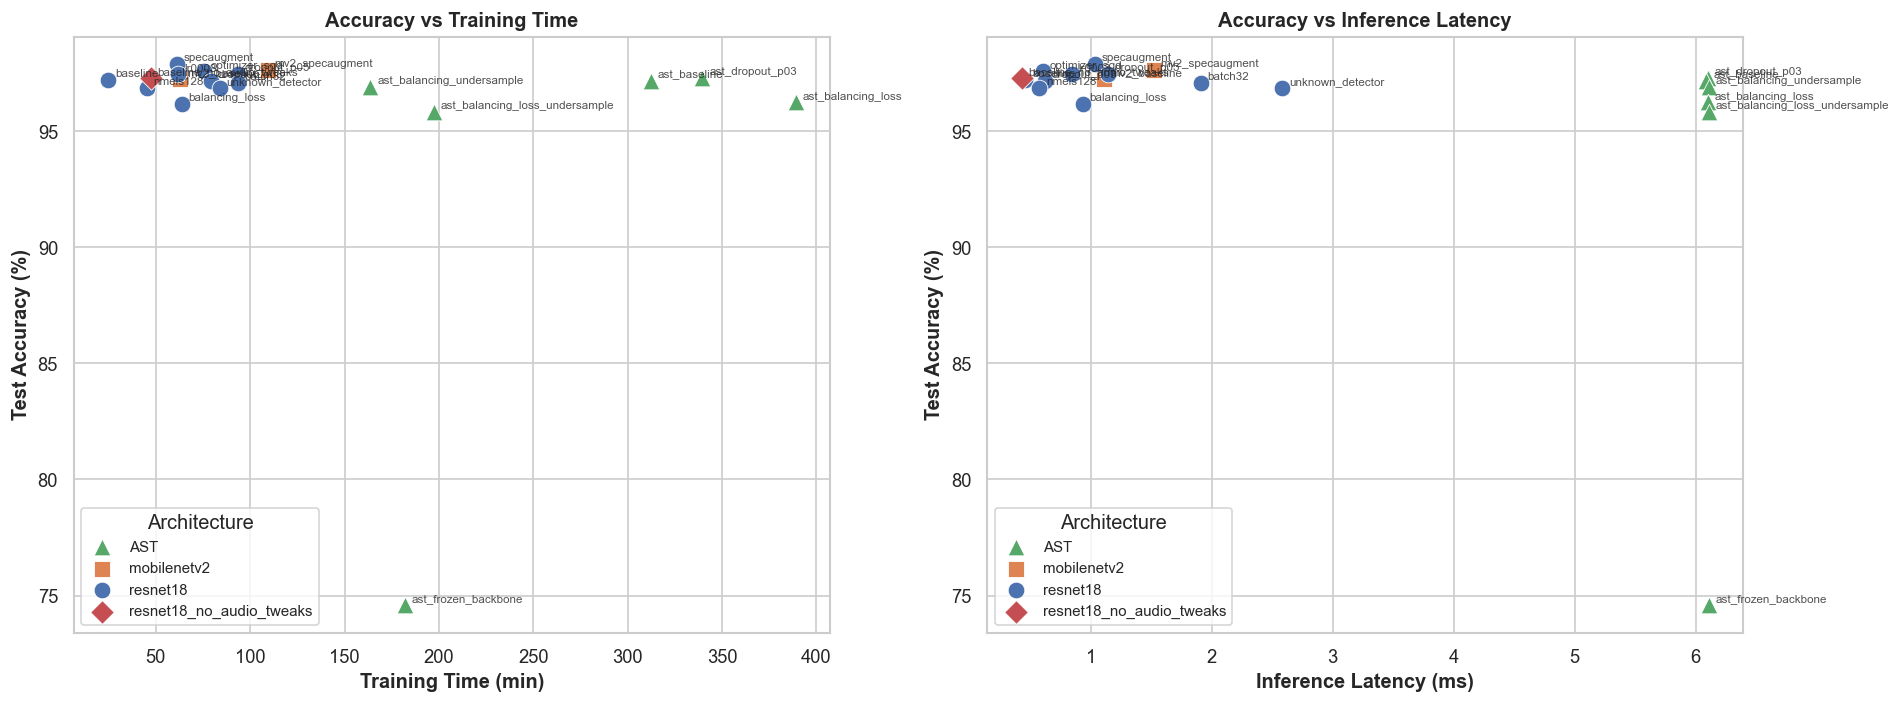

In [5]:
palette_arch = {"resnet18": "#4C72B0", "mobilenetv2": "#DD8452",
                "AST": "#55A868", "resnet18_no_audio_tweaks": "#C44E52"}
markers_arch = {"resnet18": "o", "mobilenetv2": "s", "AST": "^", "resnet18_no_audio_tweaks": "D"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for arch, grp in df.groupby("Architecture"):
    color = palette_arch.get(arch, "grey")
    marker = markers_arch.get(arch, "o")
    axes[0].scatter(grp["Train Time Mean (min)"], grp["Test Acc Mean"],
                    c=color, marker=marker, s=100, label=arch, edgecolors="white", linewidths=0.5)
    axes[1].scatter(grp["Inference Latency Mean (ms)"], grp["Test Acc Mean"],
                    c=color, marker=marker, s=100, label=arch, edgecolors="white", linewidths=0.5)

# Annotate points
for _, row in df.iterrows():
    axes[0].annotate(row["Label"], (row["Train Time Mean (min)"], row["Test Acc Mean"]),
                     textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)
    axes[1].annotate(row["Label"], (row["Inference Latency Mean (ms)"], row["Test Acc Mean"]),
                     textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)

for ax, xlabel in zip(axes, ["Training Time (min)", "Inference Latency (ms)"]):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel("Test Accuracy (%)", fontweight="bold")
    ax.legend(title="Architecture", fontsize=9)

axes[0].set_title("Accuracy vs Training Time", fontweight="bold")
axes[1].set_title("Accuracy vs Inference Latency", fontweight="bold")

plt.tight_layout()
plt.savefig("visualizations/efficiency_frontier_new.png", bbox_inches="tight")
plt.show()


## 5. No-Override Evaluation (ResNet18) — with vs without Silence
Comparison of the standard test (with silence override) vs official evaluation modes.


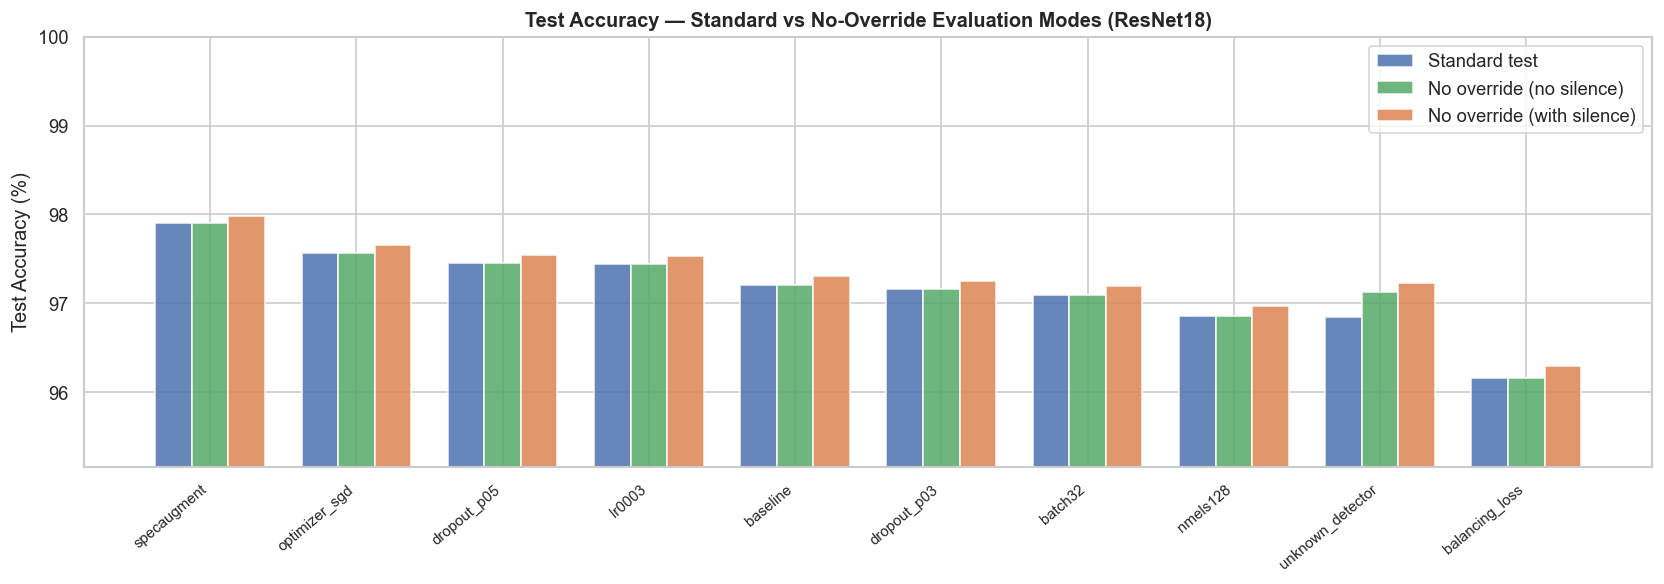

,Label,Test Acc Mean,No Ov Test Acc Mean,No Ov Sil Test Acc Mean,Δ no-sil,Δ with-sil
8,specaugment,97.9078,97.9078,97.9817,0.000,0.074
9,optimizer_sgd,97.5713,97.5713,97.6535,0.000,0.082
10,dropout_p05,97.4494,97.4494,97.5394,0.000,0.090
11,lr0003,97.4433,97.4433,97.5335,0.000,0.090
12,baseline,97.2092,97.2092,97.3077,0.000,0.099
13,dropout_p03,97.1617,97.1617,97.2512,0.000,0.090
14,batch32,97.0958,97.0958,97.1912,0.000,0.095
15,nmels128,96.8581,96.8581,96.9689,0.000,0.111
17,balancing_loss,96.1668,96.1668,96.3020,0.000,0.135
16,unknown_detector,96.8471,97.1251,97.2265,0.278,0.379


In [6]:
no_ov = df[df["No Ov Test Acc Mean"].notna()].copy()
no_ov["Label"] = no_ov["Experiment"].str.replace("resnet18_full_", "", regex=False)

x = np.arange(len(no_ov))
w = 0.25
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w, no_ov["Test Acc Mean"], w, label="Standard test", color="#4C72B0", alpha=0.85)
ax.bar(x,     no_ov["No Ov Test Acc Mean"], w, label="No override (no silence)", color="#55A868", alpha=0.85)
ax.bar(x + w, no_ov["No Ov Sil Test Acc Mean"], w, label="No override (with silence)", color="#DD8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(no_ov["Label"], rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy — Standard vs No-Override Evaluation Modes (ResNet18)", fontweight="bold")
ax.legend()
ax.set_ylim(no_ov[["Test Acc Mean","No Ov Test Acc Mean","No Ov Sil Test Acc Mean"]].min().min() - 1, 100)

plt.tight_layout()
plt.savefig("visualizations/no_override_comparison.png", bbox_inches="tight")
plt.show()

# Delta table
delta = no_ov[["Label", "Test Acc Mean", "No Ov Test Acc Mean", "No Ov Sil Test Acc Mean"]].copy()
delta["Δ no-sil"] = (delta["No Ov Test Acc Mean"] - delta["Test Acc Mean"]).round(3)
delta["Δ with-sil"] = (delta["No Ov Sil Test Acc Mean"] - delta["Test Acc Mean"]).round(3)
delta.sort_values("Δ no-sil")


## 6. Per-Class Accuracy (ResNet18 — averaged over seeds)


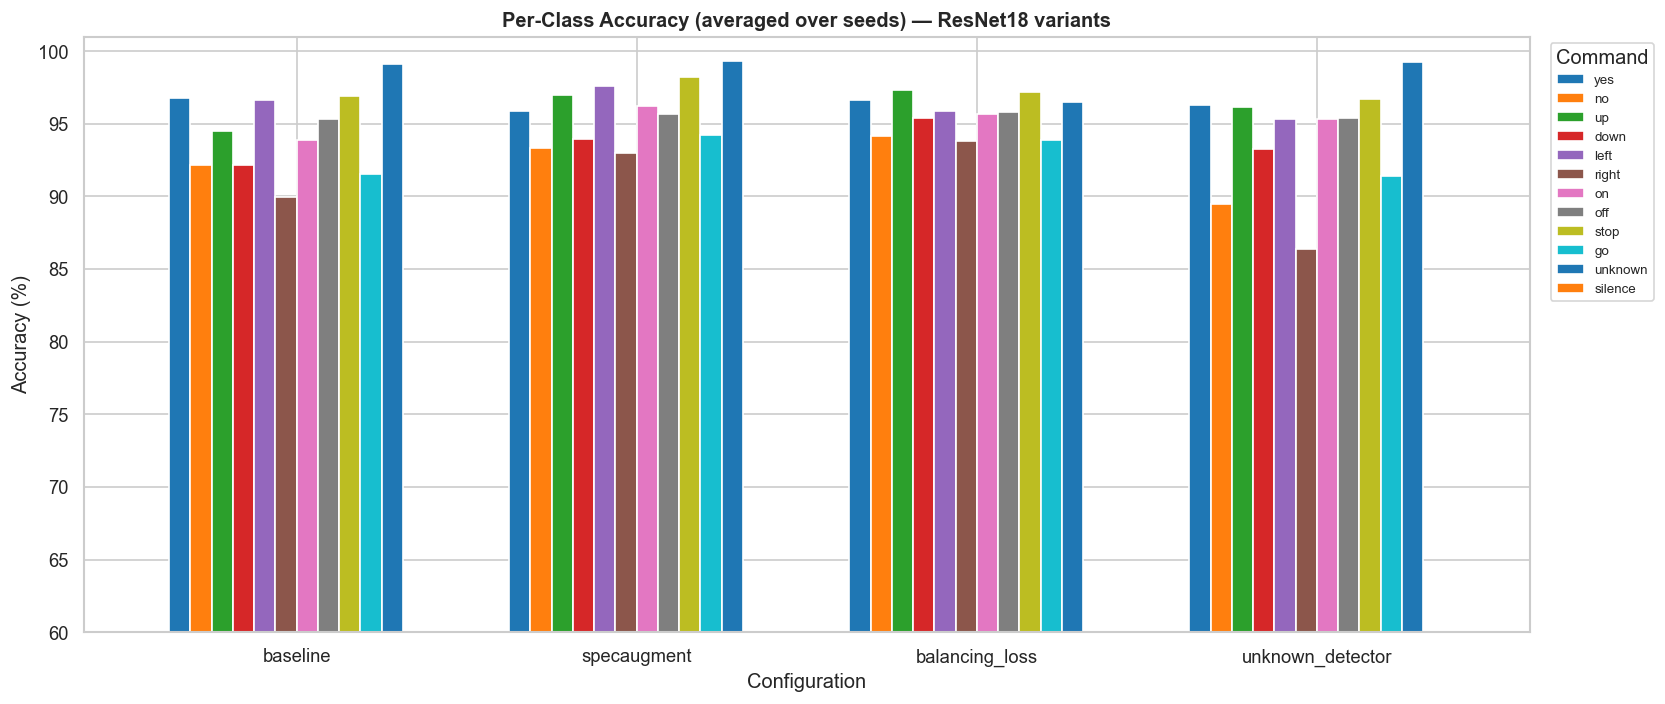


Per-class accuracy table:


In [7]:
CM_DIR = Path("../outputs/analysis/eval_no_override")

def load_avg_cm(exp_name):
    """Load all per-seed confusion matrices for an experiment and average them."""
    cms, class_names = [], []
    for jf in sorted(CM_DIR.glob(f"{exp_name}_seed*_no_override_confusion_matrix.json")):
        d = json.loads(jf.read_text())
        if not class_names:
            class_names = d.get("class_names", [])
        cm = np.array(d.get("confusion_matrix", []))
        if cm.size:
            cms.append(cm)
    if not cms:
        return None, None
    return np.mean(cms, axis=0), class_names

def per_class_acc(cm):
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return (cm.diagonal() / row_sums.squeeze()) * 100

configs_to_compare = {
    "baseline":         "resnet18_full_baseline",
    "specaugment":      "resnet18_full_specaugment",
    "balancing_loss":   "resnet18_full_balancing_loss",
    "unknown_detector": "resnet18_full_unknown_detector",
}

class_accs = {}
class_names_ref = None
for label, exp in configs_to_compare.items():
    cm, names = load_avg_cm(exp)
    if cm is not None:
        class_accs[label] = per_class_acc(cm)
        if class_names_ref is None:
            class_names_ref = names

if class_accs and class_names_ref:
    df_cls = pd.DataFrame(class_accs, index=class_names_ref)

    fig, ax = plt.subplots(figsize=(14, 6))
    df_cls.T.plot(kind="bar", ax=ax, width=0.75, edgecolor="white")
    ax.set_title("Per-Class Accuracy (averaged over seeds) — ResNet18 variants", fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Configuration")
    ax.legend(title="Command", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_ylim(60, 101)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("visualizations/per_class_accuracy_new.png", bbox_inches="tight")
    plt.show()

    print("\nPer-class accuracy table:")
    df_cls.round(1)
else:
    print("No confusion matrix files found — run eval_no_override first.")


## 7. Val vs Test Accuracy — Overfitting Check


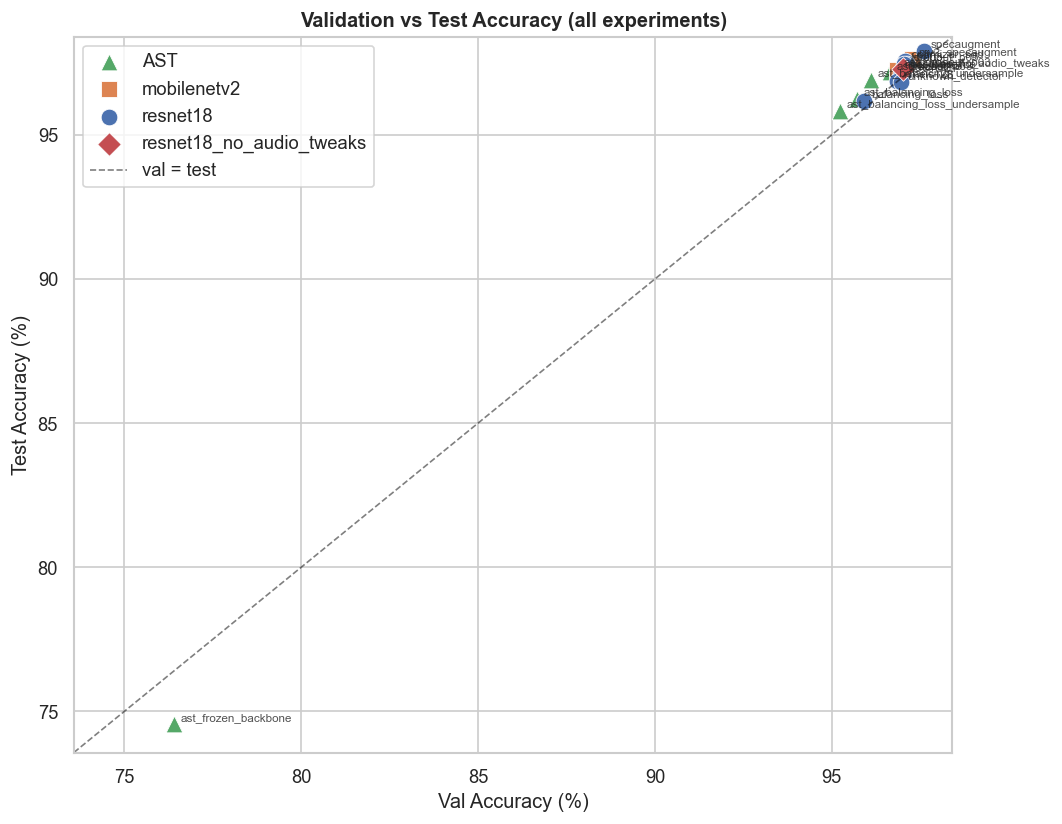

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

for arch, grp in df.groupby("Architecture"):
    color = palette_arch.get(arch, "grey")
    marker = markers_arch.get(arch, "o")
    ax.scatter(grp["Val Acc Mean"], grp["Test Acc Mean"],
               c=color, marker=marker, s=100, label=arch, edgecolors="white", linewidths=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["Label"], (row["Val Acc Mean"], row["Test Acc Mean"]),
                    textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)

lims = [min(df["Val Acc Mean"].min(), df["Test Acc Mean"].min()) - 1,
        max(df["Val Acc Mean"].max(), df["Test Acc Mean"].max()) + 0.5]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="val = test")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Val Accuracy (%)"); ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Validation vs Test Accuracy (all experiments)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/val_vs_test_acc.png", bbox_inches="tight")
plt.show()


## 8. Full Results Table


In [9]:
cols_show = ["Experiment", "Architecture", "Seeds",
             "Test Acc Mean", "Test Acc Std", "Test F1 Mean", "Test F1 Std",
             "Val Acc Mean", "Train Time Mean (min)", "Inference Latency Mean (ms)",
             "No Ov Test Acc Mean", "No Ov Sil Test Acc Mean"]

styled = (df[cols_show]
    .sort_values(["Architecture", "Test Acc Mean"], ascending=[True, False])
    .reset_index(drop=True)
    .style
    .background_gradient(subset=["Test Acc Mean", "Test F1 Mean"], cmap="YlGn")
    .format({c: "{:.2f}" for c in cols_show if df[c].dtype == float}, na_rep="—")
)
styled


,Experiment,Architecture,Seeds,Test Acc Mean,Test Acc Std,Test F1 Mean,Test F1 Std,Val Acc Mean,Train Time Mean (min),Inference Latency Mean (ms),No Ov Test Acc Mean,No Ov Sil Test Acc Mean
0,ast_full_dropout_p03,AST,4,97.28,0.35,87.86,0.49,96.83,339.65,6.10,—,—
1,ast_full_baseline,AST,4,97.18,0.06,87.68,0.10,96.64,312.46,6.09,—,—
2,ast_full_balancing_undersample,AST,4,96.90,0.20,87.30,0.26,96.10,163.73,6.11,—,—
3,ast_full_balancing_loss,AST,4,96.24,0.86,86.24,1.24,95.70,388.97,6.10,—,—
4,ast_full_balancing_loss_undersample,AST,4,95.84,0.57,85.74,0.76,95.24,197.25,6.11,—,—
5,ast_full_frozen_backbone,AST,4,74.58,0.34,48.70,1.04,76.39,182.19,6.11,—,—
6,mobilenetv2_full_specaugment,mobilenetv2,4,97.65,0.13,96.37,0.28,97.26,109.37,1.52,—,—
7,mobilenetv2_full_baseline,mobilenetv2,4,97.26,0.12,95.82,0.26,96.86,62.97,1.11,—,—
8,resnet18_full_specaugment,resnet18,4,97.91,0.20,96.87,0.39,97.61,61.18,1.03,97.91,97.98
9,resnet18_full_optimizer_sgd,resnet18,4,97.57,0.14,96.23,0.20,97.06,75.35,0.60,97.57,97.65
